In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("datos/datos.csv")
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

In [3]:
columnas = ["revenue", "copiessold", "reviewscore"] # vamos a basarnos en estas 3 columnas que son mas descriptivas de "exito"
df = df.dropna(subset=["release_date","genres", "price"]+ columnas)
#sacamos el mes y mapeamos para hacerlo mas facil de entender
df["month"] = df["release_date"].dt.month
"""
mes_map = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
df["month_name"] = df["month"].map(mes_map)
"""

'\nmes_map = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}\ndf["month_name"] = df["month"].map(mes_map)\n'

In [4]:
lista = ["genres", "categories"]
cuantitativas = ["price"]
df["month"] = df["month"].astype(str)
cualitativas = ["month"]

originales = df[cuantitativas + cualitativas + lista].copy()

df_cuantitativo = originales[cuantitativas].copy()
df_lista = originales[lista].copy()
df_cualitativo = originales[cualitativas].copy()

df_binarizado = pd.DataFrame(index=df_lista.index)
for columnas in lista:
    listas = df_lista[columnas].fillna("").astype(str).str.split(",")
    mlb = MultiLabelBinarizer()
    binarizado = mlb.fit_transform(listas)
    temp = pd.DataFrame(binarizado, columns=mlb.classes, index=df_lista.index).add_prefix(f"{columnas}_")
    df_binarizado = pd.concat([df_binarizado, temp], axis=1)

In [5]:
df_cuantitativo = df[cuantitativas]
df_para_pca = pd.concat([df_cuantitativo, df_binarizado], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_para_pca)
X_scaled = pd.DataFrame(X_scaled, columns=df_para_pca.columns, index=df_para_pca.index)
pca = PCA(n_components=min(27, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_.sum()
print(f"Varianza explicada por las primeras {pca.n_components_} componentes principales: {explained:.3%}")

#convertimos el df 
column_names_pca = [f"PCA_{i}" for i in range(X_pca.shape[1])]
df_pca_final = pd.DataFrame(X_pca, columns=column_names_pca, index=df.index)

Varianza explicada por las primeras 27 componentes principales: 1.269%


In [6]:
df_cualitativo = df[["month"]].copy()
encoder = OneHotEncoder(
    min_frequency=100,
    handle_unknown='ignore',
    dtype=np.float32,
    drop=None
)

mes_resultado = encoder.fit_transform(df_cualitativo)
columnas_mes = encoder.get_feature_names_out(df_cualitativo.columns)
df_mes = pd.DataFrame(mes_resultado.toarray(), columns=columnas_mes, index=df_cualitativo.index)

In [7]:
#unimos los meses limpios, el pca (resumen de precio y generos)
columnas = ["revenue", "copiessold", "reviewscore"]
df_final = pd.concat([df_mes, df_pca_final], axis=1)

#entrenamos la regresion para buscar el mejor mes
resultados = {}
columnas_meses = [col for col in df_final.columns if col.startswith("month_")]
for columna in columnas:
    y = df[columna]
    modelo = LinearRegression(fit_intercept=False) #PONEMOS ESTO EN FALSO POR EL ONE HOT
    modelo.fit(df_final, y)
    resultados[columna] = pd.Series(modelo.coef_, index=df_final.columns)[columnas_meses]

In [8]:
coefs = pd.DataFrame(resultados)

coefs["mes_num"] = coefs.index.str.extract("(\d+)", expand=False).astype(int)
mes_coefs = coefs.sort_values("mes_num")

mapa_meses = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
mes_coefs.index = mes_coefs["mes_num"].map(mapa_meses)
mes_coefs = mes_coefs.drop(columns=["mes_num"])

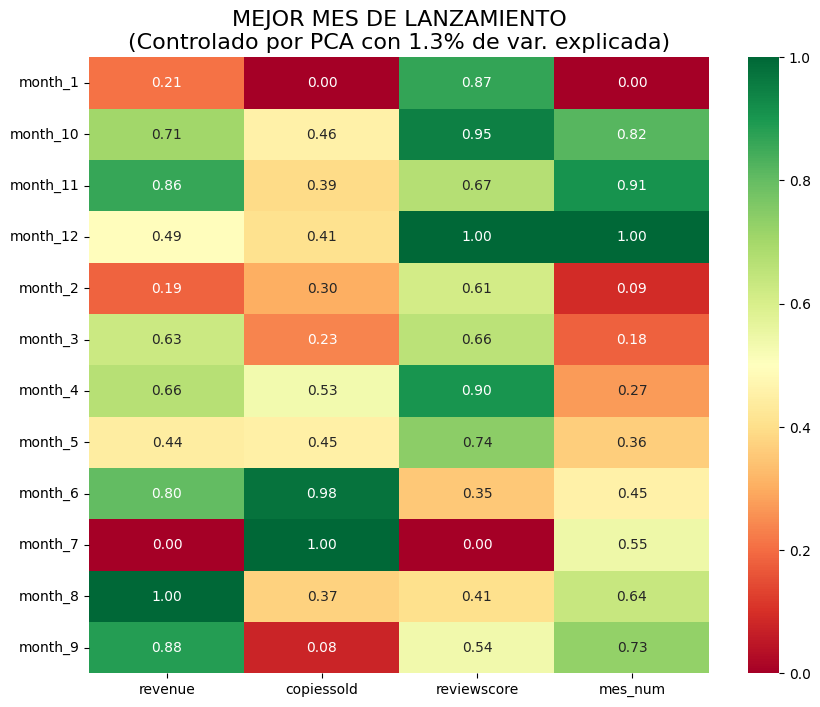

In [9]:
scaler_plot = MinMaxScaler()
df_plot = pd.DataFrame(scaler_plot.fit_transform(coefs), 
                       index=coefs.index, columns=coefs.columns)

plt.figure(figsize=(10, 8))
sns.heatmap(df_plot, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title(f"MEJOR MES DE LANZAMIENTO\n(Controlado por PCA con {explained:.1%} de var. explicada)", fontsize=16)
plt.show()

En el mes de Junio tenemos SUMMER SALES y Diciembre las WINTER SAlES, son buenos para aumentar el volumen de ventas pero no tanto de revenue, ya que bajan los precios. 

En julio pareciera que se vende mucho pero no ganas tanto (baja de precios) y peores notas se reciben. (?)

Enero parece el mes mas flojo de todos. 

Para maximizar review score: Febrero y octubre. 

Para maximizar jugadores: Julio y Junio, mayores copias vendidas. 

Para maximizar ganancias: Agosto. 